# Usage of PySpark SQL

In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [2]:
spark

In [3]:
sc = spark.sparkContext

In [4]:
## documentation
spark.read??

In [5]:
file_path = r'article_source.txt'

In [6]:
article = spark.read.text(file_path)

In [7]:
article

DataFrame[value: string]

In [8]:
article.printSchema()

root
 |-- value: string (nullable = true)



In [9]:
article.select(article.value)

DataFrame[value: string]

In [10]:
article.show(5, truncate=False)

+--------------------------------------------------------------------------+
|value                                                                     |
+--------------------------------------------------------------------------+
|The United Arab Emirates is quitting OPEC oil cartel after nearly 60 years|
|By Camila Domonoske                                                       |
|Updated Tuesday, April 28, 2026 • 5:11 PM EDT                             |
|Heard on All Things Considered                                            |
|Stay up to date with our Up First newsletter sent every weekday morning.  |
+--------------------------------------------------------------------------+
only showing top 5 rows


In [11]:
from pyspark.sql.functions import col

In [12]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [13]:
from pyspark.sql.functions import col, split

lines = article.select(
    split(col('value'), " ").alias('line')
)

In [14]:
lines.printSchema()

root
 |-- line: array (nullable = true)
 |    |-- element: string (containsNull = false)



In [15]:
lines.show(5, truncate=False)

+----------------------------------------------------------------------------------------+
|line                                                                                    |
+----------------------------------------------------------------------------------------+
|[The, United, Arab, Emirates, is, quitting, OPEC, oil, cartel, after, nearly, 60, years]|
|[By, Camila, Domonoske]                                                                 |
|[Updated, Tuesday,, April, 28,, 2026, •, 5:11, PM, EDT]                                 |
|[Heard, on, All, Things, Considered]                                                    |
|[Stay, up, to, date, with, our, Up, First, newsletter, sent, every, weekday, morning.]  |
+----------------------------------------------------------------------------------------+
only showing top 5 rows


In [16]:
lines

DataFrame[line: array<string>]

In [17]:
from pyspark.sql.functions import explode

words = lines.select(explode(col("line")).alias('word'))

In [18]:
words.printSchema()

root
 |-- word: string (nullable = false)



In [19]:
from pyspark.sql.functions import lower

words_lower = words.select(lower(col("word")).alias('word_lower'))

In [20]:
words_lower.show(10)

+----------+
|word_lower|
+----------+
|       the|
|    united|
|      arab|
|  emirates|
|        is|
|  quitting|
|      opec|
|       oil|
|    cartel|
|     after|
+----------+
only showing top 10 rows


In [21]:
from pyspark.sql.functions import regexp_extract

words_clean = words_lower.select(
    regexp_extract(col("word_lower"), r"(\W+)?([a-z]+)", 2).alias("word_clean")
)

In [22]:
words_clean.show(10)

+----------+
|word_clean|
+----------+
|       the|
|    united|
|      arab|
|  emirates|
|        is|
|  quitting|
|      opec|
|       oil|
|    cartel|
|     after|
+----------+
only showing top 10 rows


In [23]:
words_nonull = words_clean.where(col("word_clean") != "")

words_nonull.show(100)

+------------+
|  word_clean|
+------------+
|         the|
|      united|
|        arab|
|    emirates|
|          is|
|    quitting|
|        opec|
|         oil|
|      cartel|
|       after|
|      nearly|
|       years|
|          by|
|      camila|
|   domonoske|
|     updated|
|     tuesday|
|       april|
|          pm|
|         edt|
|       heard|
|          on|
|         all|
|      things|
|  considered|
|        stay|
|          up|
|          to|
|        date|
|        with|
|         our|
|          up|
|       first|
|  newsletter|
|        sent|
|       every|
|     weekday|
|     morning|
|         the|
|      united|
|        arab|
|    emirates|
|         has|
|   announced|
|        that|
|          it|
|     leaving|
|        opec|
|         the|
|      cartel|
|representing|
|       major|
|       state|
|         oil|
|   producers|
|          on|
|         may|
|          in|
|          an|
|announcement|
|      posted|
|          on|
|       state|
|       me

In [24]:
groups = words_nonull.groupBy(col("word_clean"))

In [25]:
groups

GroupedData[grouping expressions: [word_clean], value: [word_clean: string], type: GroupBy]

In [26]:
counts = groups.count()

In [27]:
counts.orderBy('count', ascending=False).show(10)

+----------+-----+
|word_clean|count|
+----------+-----+
|       the|  122|
|       oil|   52|
|        of|   46|
|        to|   40|
|       and|   40|
|         a|   39|
|        in|   35|
|      opec|   32|
|       uae|   31|
|      that|   28|
+----------+-----+
only showing top 10 rows


In [28]:
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .groupby('word')
     .count()
)

In [29]:
counts.show(10)

+---------+-----+
|     word|count|
+---------+-----+
|      few|    2|
|     some|    4|
|    those|    3|
|      hub|    1|
|countries|    6|
|   israel|    2|
|  traffic|    2|
|    leave|    2|
|      don|    1|
|      uae|   31|
+---------+-----+
only showing top 10 rows


## **In Class Exercise**

Then do the following:
1. Remove words with 3 or fewer letters
2. Return the top 5 words and there occurrence frequency
3. Produce histogram of each letter in the alphabet ordered from highest to lowest frequency

In [30]:
counts_filtered = counts.where(F.length(F.col('word')) > 3)

In [31]:
counts_filtered.orderBy(F.col('count').desc()).show(5)

+----+-----+
|word|count|
+----+-----+
|opec|   32|
|that|   28|
|they|   19|
|more|   16|
|have|   14|
+----+-----+
only showing top 5 rows


In [32]:
letter_counts = (
    spark.read.text(file_path)
    .select(F.explode(F.split(F.col('value'), '')).alias('letter'))
    .select(F.lower(F.col('letter')).alias('letter'))
    .where(F.col('letter').rlike('^[a-z]$'))
    .groupby('letter')
    .count()
    .orderBy(F.col('count').desc())
)

letter_counts.show(26)

+------+-----+
|letter|count|
+------+-----+
|     e| 1006|
|     t|  789|
|     o|  722|
|     a|  709|
|     i|  560|
|     r|  553|
|     s|  522|
|     n|  512|
|     h|  397|
|     l|  365|
|     u|  309|
|     c|  307|
|     d|  278|
|     p|  218|
|     m|  212|
|     g|  154|
|     f|  146|
|     y|  146|
|     w|  124|
|     b|  108|
|     v|   66|
|     k|   60|
|     j|   17|
|     q|   11|
|     z|    9|
|     x|    7|
+------+-----+



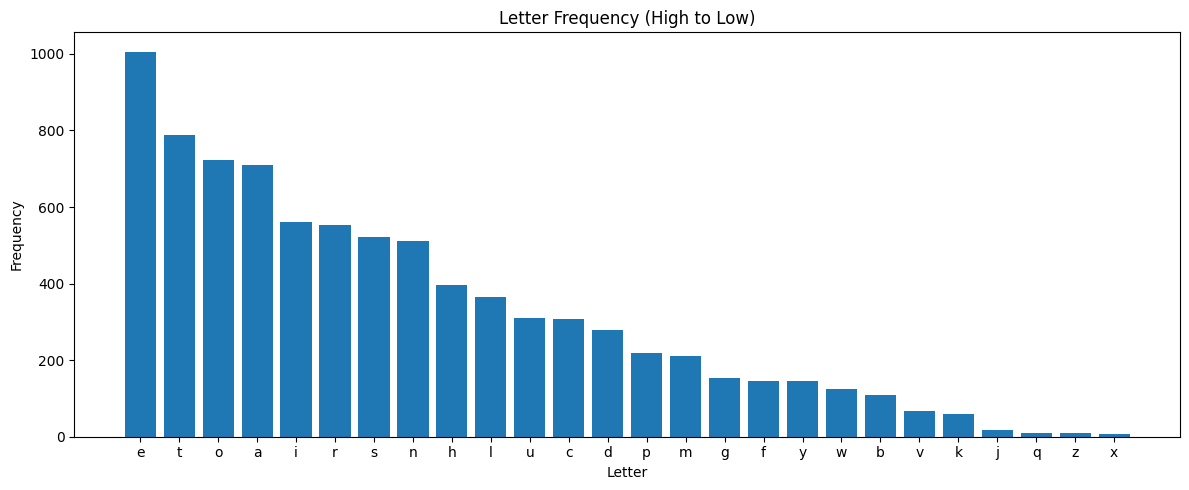

In [33]:
import matplotlib.pyplot as plt

df = letter_counts.toPandas()

plt.figure(figsize=(12, 5))
plt.bar(df['letter'], df['count'])
plt.xlabel('Letter')
plt.ylabel('Frequency')
plt.title('Letter Frequency (High to Low)')
plt.tight_layout()
plt.show()